In [1]:
import pandas as pd
import numpy as np

# Charger le dataset
df = pd.read_csv('../data/cicids2017.csv')

# Premiers aperçus
print("Shape:", df.shape)
print("\nColonnes:", df.columns.tolist())
print("\nTypes:", df.dtypes)
df.head()

Shape: (2520751, 53)

Colonnes: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Max', 'Active Mi

,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic


In [2]:
# Distribution des classes
print("Distribution des attaques :")
print(df['Attack Type'].value_counts())
print("\nNombre de classes :", df['Attack Type'].nunique())

Distribution des attaques :
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64

Nombre de classes : 7


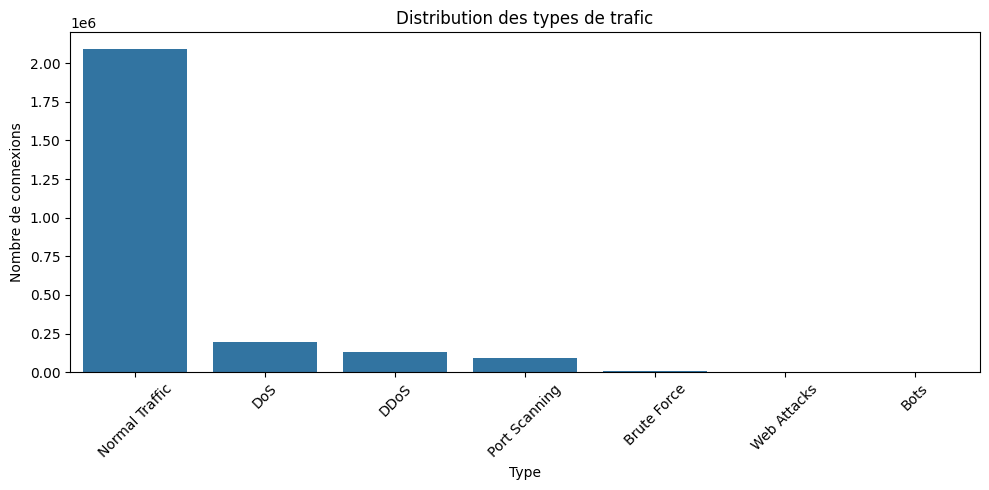


Pourcentages :
Attack Type
Normal Traffic    83.11
DoS                7.69
DDoS               5.08
Port Scanning      3.60
Brute Force        0.36
Web Attacks        0.09
Bots               0.08
Name: count, dtype: float64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(x=df['Attack Type'].value_counts().index, 
            y=df['Attack Type'].value_counts().values)
plt.title('Distribution des types de trafic')
plt.xlabel('Type')
plt.ylabel('Nombre de connexions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pourcentages
print("\nPourcentages :")
print((df['Attack Type'].value_counts() / len(df) * 100).round(2))

In [4]:
# Valeurs manquantes
print("Valeurs manquantes :")
print(df.isnull().sum().sum(), "valeurs manquantes au total")

# Valeurs infinies
print("\nValeurs infinies :")
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum(), "valeurs infinies au total")

# Doublons
print("\nDoublons :")
print(df.duplicated().sum(), "doublons au total")

Valeurs manquantes :
0 valeurs manquantes au total

Valeurs infinies :
0 valeurs infinies au total

Doublons :
161 doublons au total


In [5]:
# Supprimer les doublons
df = df.drop_duplicates()
print("Shape après suppression des doublons:", df.shape)

Shape après suppression des doublons: (2520590, 53)


In [6]:
# Sauvegarder
df.to_csv('../data/cicids_clean.csv', index=False)
print("Dataset sauvegardé !")

Dataset sauvegardé !


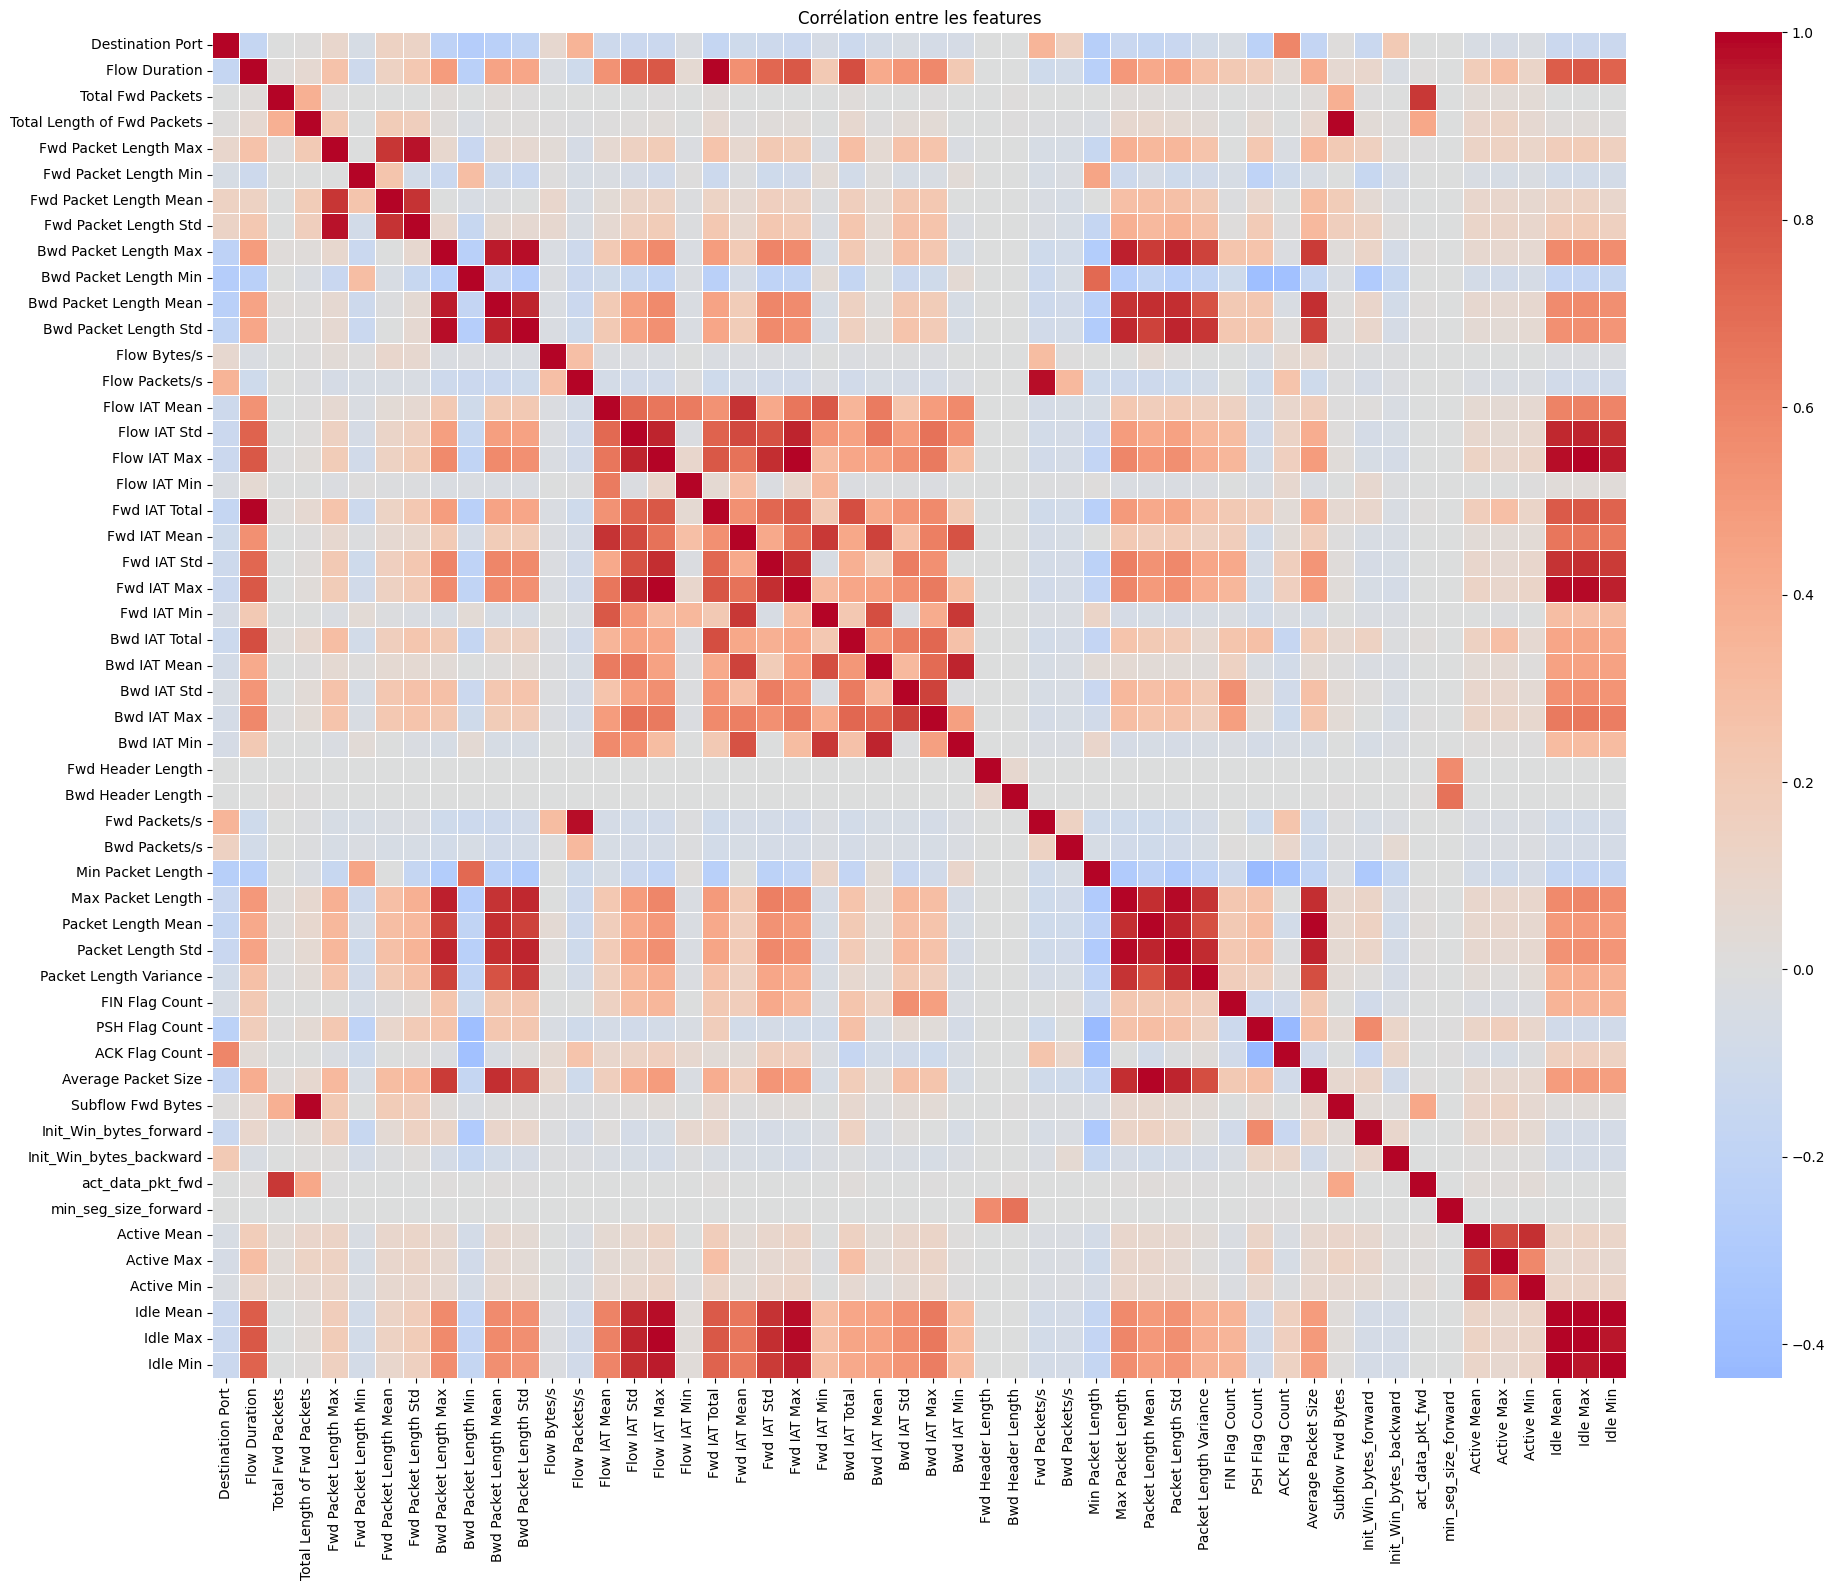

In [7]:
# Heatmap de corrélation
plt.figure(figsize=(20, 16))
sns.heatmap(df.select_dtypes(include=np.number).corr(), 
            cmap='coolwarm', 
            center=0,
            linewidths=0.5)
plt.title('Corrélation entre les features')
plt.tight_layout()
plt.show()

In [8]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib

# Encoder la colonne cible
le = LabelEncoder()
df['label'] = le.fit_transform(df['Attack Type'])

print("Classes encodées :")
for i, classe in enumerate(le.classes_):
    print(f"  {i} → {classe}")

Classes encodées :
  0 → Bots
  1 → Brute Force
  2 → DDoS
  3 → DoS
  4 → Normal Traffic
  5 → Port Scanning
  6 → Web Attacks


In [9]:
# Séparer features et label
X = df.drop(['Attack Type', 'label'], axis=1)
y = df['label']

print("Shape X:", X.shape)
print("Shape y:", y.shape)

# Diviser en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nShape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

# Vérifier la distribution
print("\nDistribution dans y_train :")
print(y_train.value_counts())

Shape X: (2520590, 52)
Shape y: (2520590,)

Shape X_train: (2016472, 52)
Shape X_test: (504118, 52)

Distribution dans y_train :
label
4    1675917
3     154996
2     102411
5      72555
1       7320
6       1714
0       1559
Name: count, dtype: int64


In [10]:
# Appliquer StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling appliqué ")

# Sauvegarder tout
joblib.dump(X_train_scaled, '../data/X_train.pkl')
joblib.dump(X_test_scaled, '../data/X_test.pkl')
joblib.dump(y_train, '../data/y_train.pkl')
joblib.dump(y_test, '../data/y_test.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(le, '../models/label_encoder.pkl')

print("Tout sauvegardé ")

Scaling appliqué 
Tout sauvegardé 
